___
<img style="float: right; margin: 0px 0px 15px 15px;" src="https://machinelearningmastery.com/wp-content/uploads/2016/03/Compare-Machine-Learning-Algorithms.png" width="350px" height="180px" />


# <font color= #8A0829> Laboratorio de Modelado de Datos </font>
#### <font color= #2E9AFE> `Martes y Viernes (Videoconferencia) de 13:00 - 15:00 hrs`</font>
- <Strong> Sara Eugenia Rodríguez </Strong>
- <Strong> Año </Strong>: 2025
- <Strong> Email: </Strong>  <font color="blue"> `sara.rodriguezr@iteso.mx` </font>
___


### <font color= #2E9AFE> Tema: Comparación de modelos de regresión</font>

## Decidir cuál modelo de ML utilizar 

Decidir cuál modelo de machine learning utilizar sin necesidad de probar todos los modelos es una habilidad que se puede desarrollar haciendo preguntas específicas sobre los datos y el problema que se quiere resolver.

**Preguntas sobre los Datos**
1. **¿Cuál es la cantidad y calidad de los datos disponibles?**

- ¿Tengo suficientes datos para entrenar un modelo complejo como una red neuronal o debo usar un modelo más simple como regresión lineal?
- ¿Mis datos tienen muchos valores faltantes, ruido o outliers? Modelos basados en árboles son más robustos a estos problemas.

- Regla General: Para modelos lineales y modelos básicos, se recomienda tener al menos 10 veces más observaciones que características. Es decir, si tienes 20 características, deberías tener al menos 200 observaciones.
- Modelos Complejos: Para modelos complejos como redes neuronales o modelos con muchas características, se recomienda tener al menos 50 a 100 veces más observaciones que características para evitar problemas de sobreajuste.

2. **¿Cuántas características tengo y cómo se relacionan entre sí?**

- Número de Características: ¿Tengo pocas o muchas características? Modelos como XGBoost y Random Forest manejan bien conjuntos de datos con muchas características.
- Relaciones Lineales o No Lineales: ¿Las relaciones entre las características y la variable objetivo parecen lineales o no lineales? Modelos lineales como la regresión lineal o SVM con kernel lineal funcionan bien con relaciones lineales, mientras que modelos como redes neuronales y SVM con kernel no lineal se ajustan mejor a relaciones complejas.

3. **¿Mis datos son numéricos, categóricos o una combinación de ambos?**

- Numéricos: La mayoría de los modelos manejan bien datos numéricos.
- Categóricos: Modelos basados en árboles pueden manejar variables categóricas de mejor forma.
- Combinación: Si tienes una combinación, considera modelos como Random Forest o XGBoost que son más versátiles con diferentes tipos de datos.


**Preguntas sobre el Problema**
1. **¿Cuál es el objetivo principal del problema?**

- Interpretabilidad vs. Precisión: Si necesitas un modelo fácilmente interpretable (por ejemplo, para justificar decisiones), podrías preferir una regresión lineal o un árbol de decisión simple. Si la precisión es más importante, modelos como Random Forest, XGBoost o redes neuronales son más apropiados.

2. **¿Qué tipo de relación esperas entre las variables independientes y la dependiente?**

- Relaciones Lineales: Usa modelos como regresión lineal o SVM lineal.
- Relaciones No Lineales: Usa modelos como SVM con kernels no lineales, Random Forest, XGBoost o redes neuronales.

3. **¿Cuánto tiempo y recursos computacionales tienes disponibles?**

- Recursos Limitados: Modelos como regresión lineal, SVM lineal y árboles de decisión son rápidos de entrenar.
- Recursos Amplios: Puedes considerar modelos más complejos como Random Forest, XGBoost y redes neuronales que pueden requerir más tiempo y recursos para entrenar.

4. **¿Necesitas un modelo que generalice bien o estás más interesado en el ajuste al conjunto de datos actual?**

- Generalización: Modelos regularizados (Ridge, Lasso), Random Forest y XGBoost tienden a generalizar mejor.
- Ajuste al Conjunto Actual: Modelos como regresión lineal o árbol de decisión sencillo pueden ajustar bien los datos actuales, pero podrían sobreajustar si no se tiene cuidado.


Si no te fue sencillo elegir un solo modelo a implementar, comparar varios modelos de machine learning es necesario para poder encontrar cuál de todos los modelos es el más eficiente y tiene los resultados más precisos. 

Recordando que si la **variable de respuesta es continua** entonces, este es un problema de **regresión** y tenemos que usar modelos de regresión para estimar los valores predichos. 

Como vimos, hay muchos modelos de regresión candidatos. Nuestra tarea es encontrar el que sirva a nuestro propósito.

Vamos a comparar los siguientes modelos:
- Regresión lineal
- SVR
- Random Forest
- XGBoost
- Neural Network
- 
Vamos a utilizar varias métricas para comparar los modelos.

### Exploracion de datos

In [1]:
import pandas as pd
import plotly.express as px
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

In [2]:
# Crear un DataFrame vacío para almacenar los datos concatenados
concatenated_data = pd.DataFrame()

# Iterar a través de los archivos CSV de 2015 a 2023
for year in range(2015, 2024):
    filename = f'WHR_{year}.csv' 
    data = pd.read_csv(filename)
    data['year'] = year
    concatenated_data = pd.concat([concatenated_data, data], ignore_index=True)  # Concatenar al DataFrame principal


In [3]:
concatenated_data.head()

,country,region,happiness_score,gdp_per_capita,social_support,healthy_life_expectancy,freedom_to_make_life_choices,generosity,perceptions_of_corruption,year
0,Switzerland,Western Europe,7.587,1.39651,1.34951,0.94143,0.66557,0.29678,0.41978,2015
1,Iceland,Western Europe,7.561,1.30232,1.40223,0.94784,0.62877,0.43630,0.14145,2015
2,Denmark,Western Europe,7.527,1.32548,1.36058,0.87464,0.64938,0.34139,0.48357,2015
3,Norway,Western Europe,7.522,1.45900,1.33095,0.88521,0.66973,0.34699,0.36503,2015
4,Canada,North America and ANZ,7.427,1.32629,1.32261,0.90563,0.63297,0.45811,0.32957,2015


In [4]:
concatenated_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1367 entries, 0 to 1366
Data columns (total 10 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   country                       1367 non-null   object 
 1   region                        1367 non-null   object 
 2   happiness_score               1367 non-null   float64
 3   gdp_per_capita                1367 non-null   float64
 4   social_support                1367 non-null   float64
 5   healthy_life_expectancy       1366 non-null   float64
 6   freedom_to_make_life_choices  1367 non-null   float64
 7   generosity                    1367 non-null   float64
 8   perceptions_of_corruption     1366 non-null   float64
 9   year                          1367 non-null   int64  
dtypes: float64(7), int64(1), object(2)
memory usage: 106.9+ KB


In [5]:
print(concatenated_data.isna().sum())

country                         0
region                          0
happiness_score                 0
gdp_per_capita                  0
social_support                  0
healthy_life_expectancy         1
freedom_to_make_life_choices    0
generosity                      0
perceptions_of_corruption       1
year                            0
dtype: int64


In [6]:
#Imputamos los datos nulos con promedios

from sklearn.impute import SimpleImputer
most_imputer = SimpleImputer(missing_values = np.nan, strategy = 'mean')

concatenated_data['healthy_life_expectancy'] = most_imputer.fit_transform(concatenated_data[["healthy_life_expectancy"]])
concatenated_data['perceptions_of_corruption'] = most_imputer.fit_transform(concatenated_data[["perceptions_of_corruption"]])

In [7]:
print("Number of duplicates in df = ", concatenated_data.duplicated().sum())

Number of duplicates in df =  0


#### Analisis Univariado

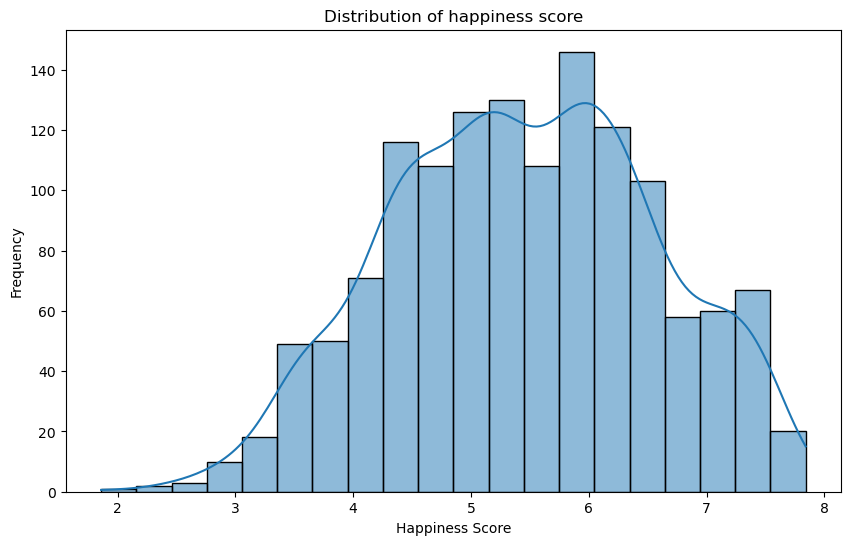

In [8]:
# Histograma del score de la felicidad
plt.figure(figsize=(10, 6))
sns.histplot(data=concatenated_data, x='happiness_score', bins=20, kde=True)
plt.title('Distribution of happiness score')
plt.xlabel('Happiness Score')
plt.ylabel('Frequency')
plt.show()

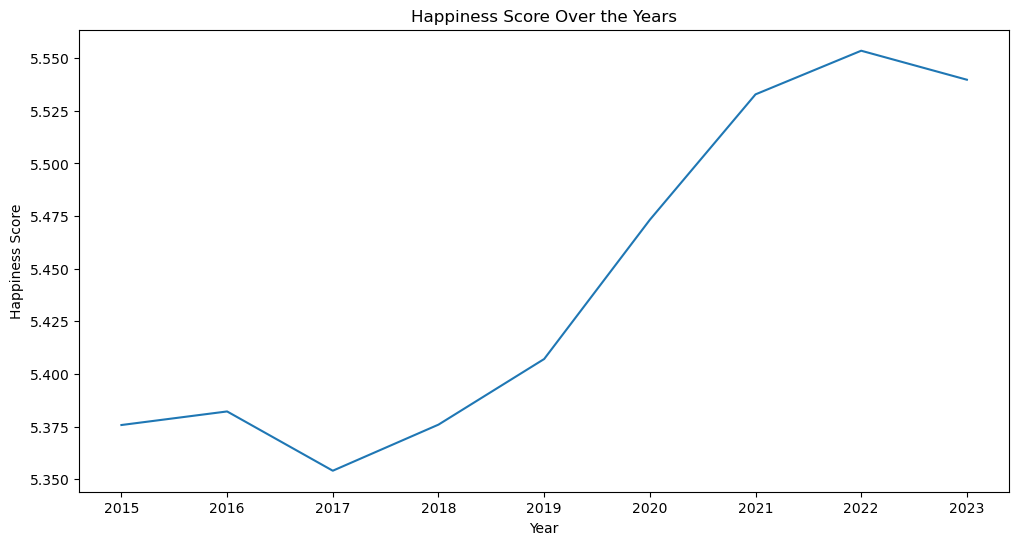

In [9]:
# score de la felicidad a lo largo de los años
plt.figure(figsize=(12, 6))
sns.lineplot(data=concatenated_data, x='year', y='happiness_score', errorbar=None)
plt.title('Happiness Score Over the Years')
plt.xlabel('Year')
plt.ylabel('Happiness Score')
plt.show()

<Axes: >

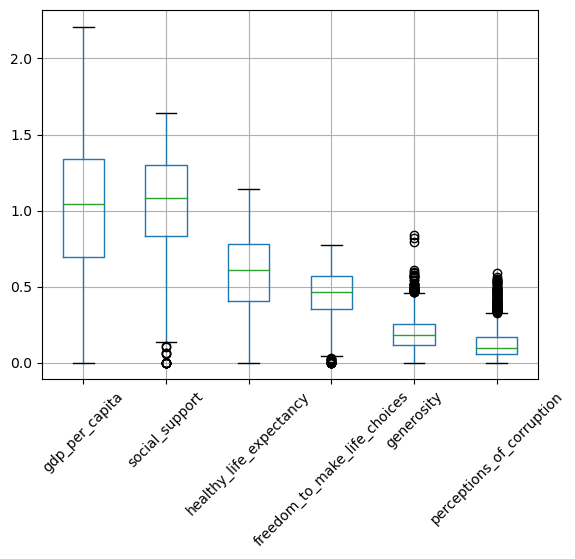

In [10]:
concatenated_data.boxplot(column=['gdp_per_capita', 'social_support',
       'healthy_life_expectancy', 'freedom_to_make_life_choices', 'generosity',
       'perceptions_of_corruption'], rot=45,)  

#### Analisis Bivariado

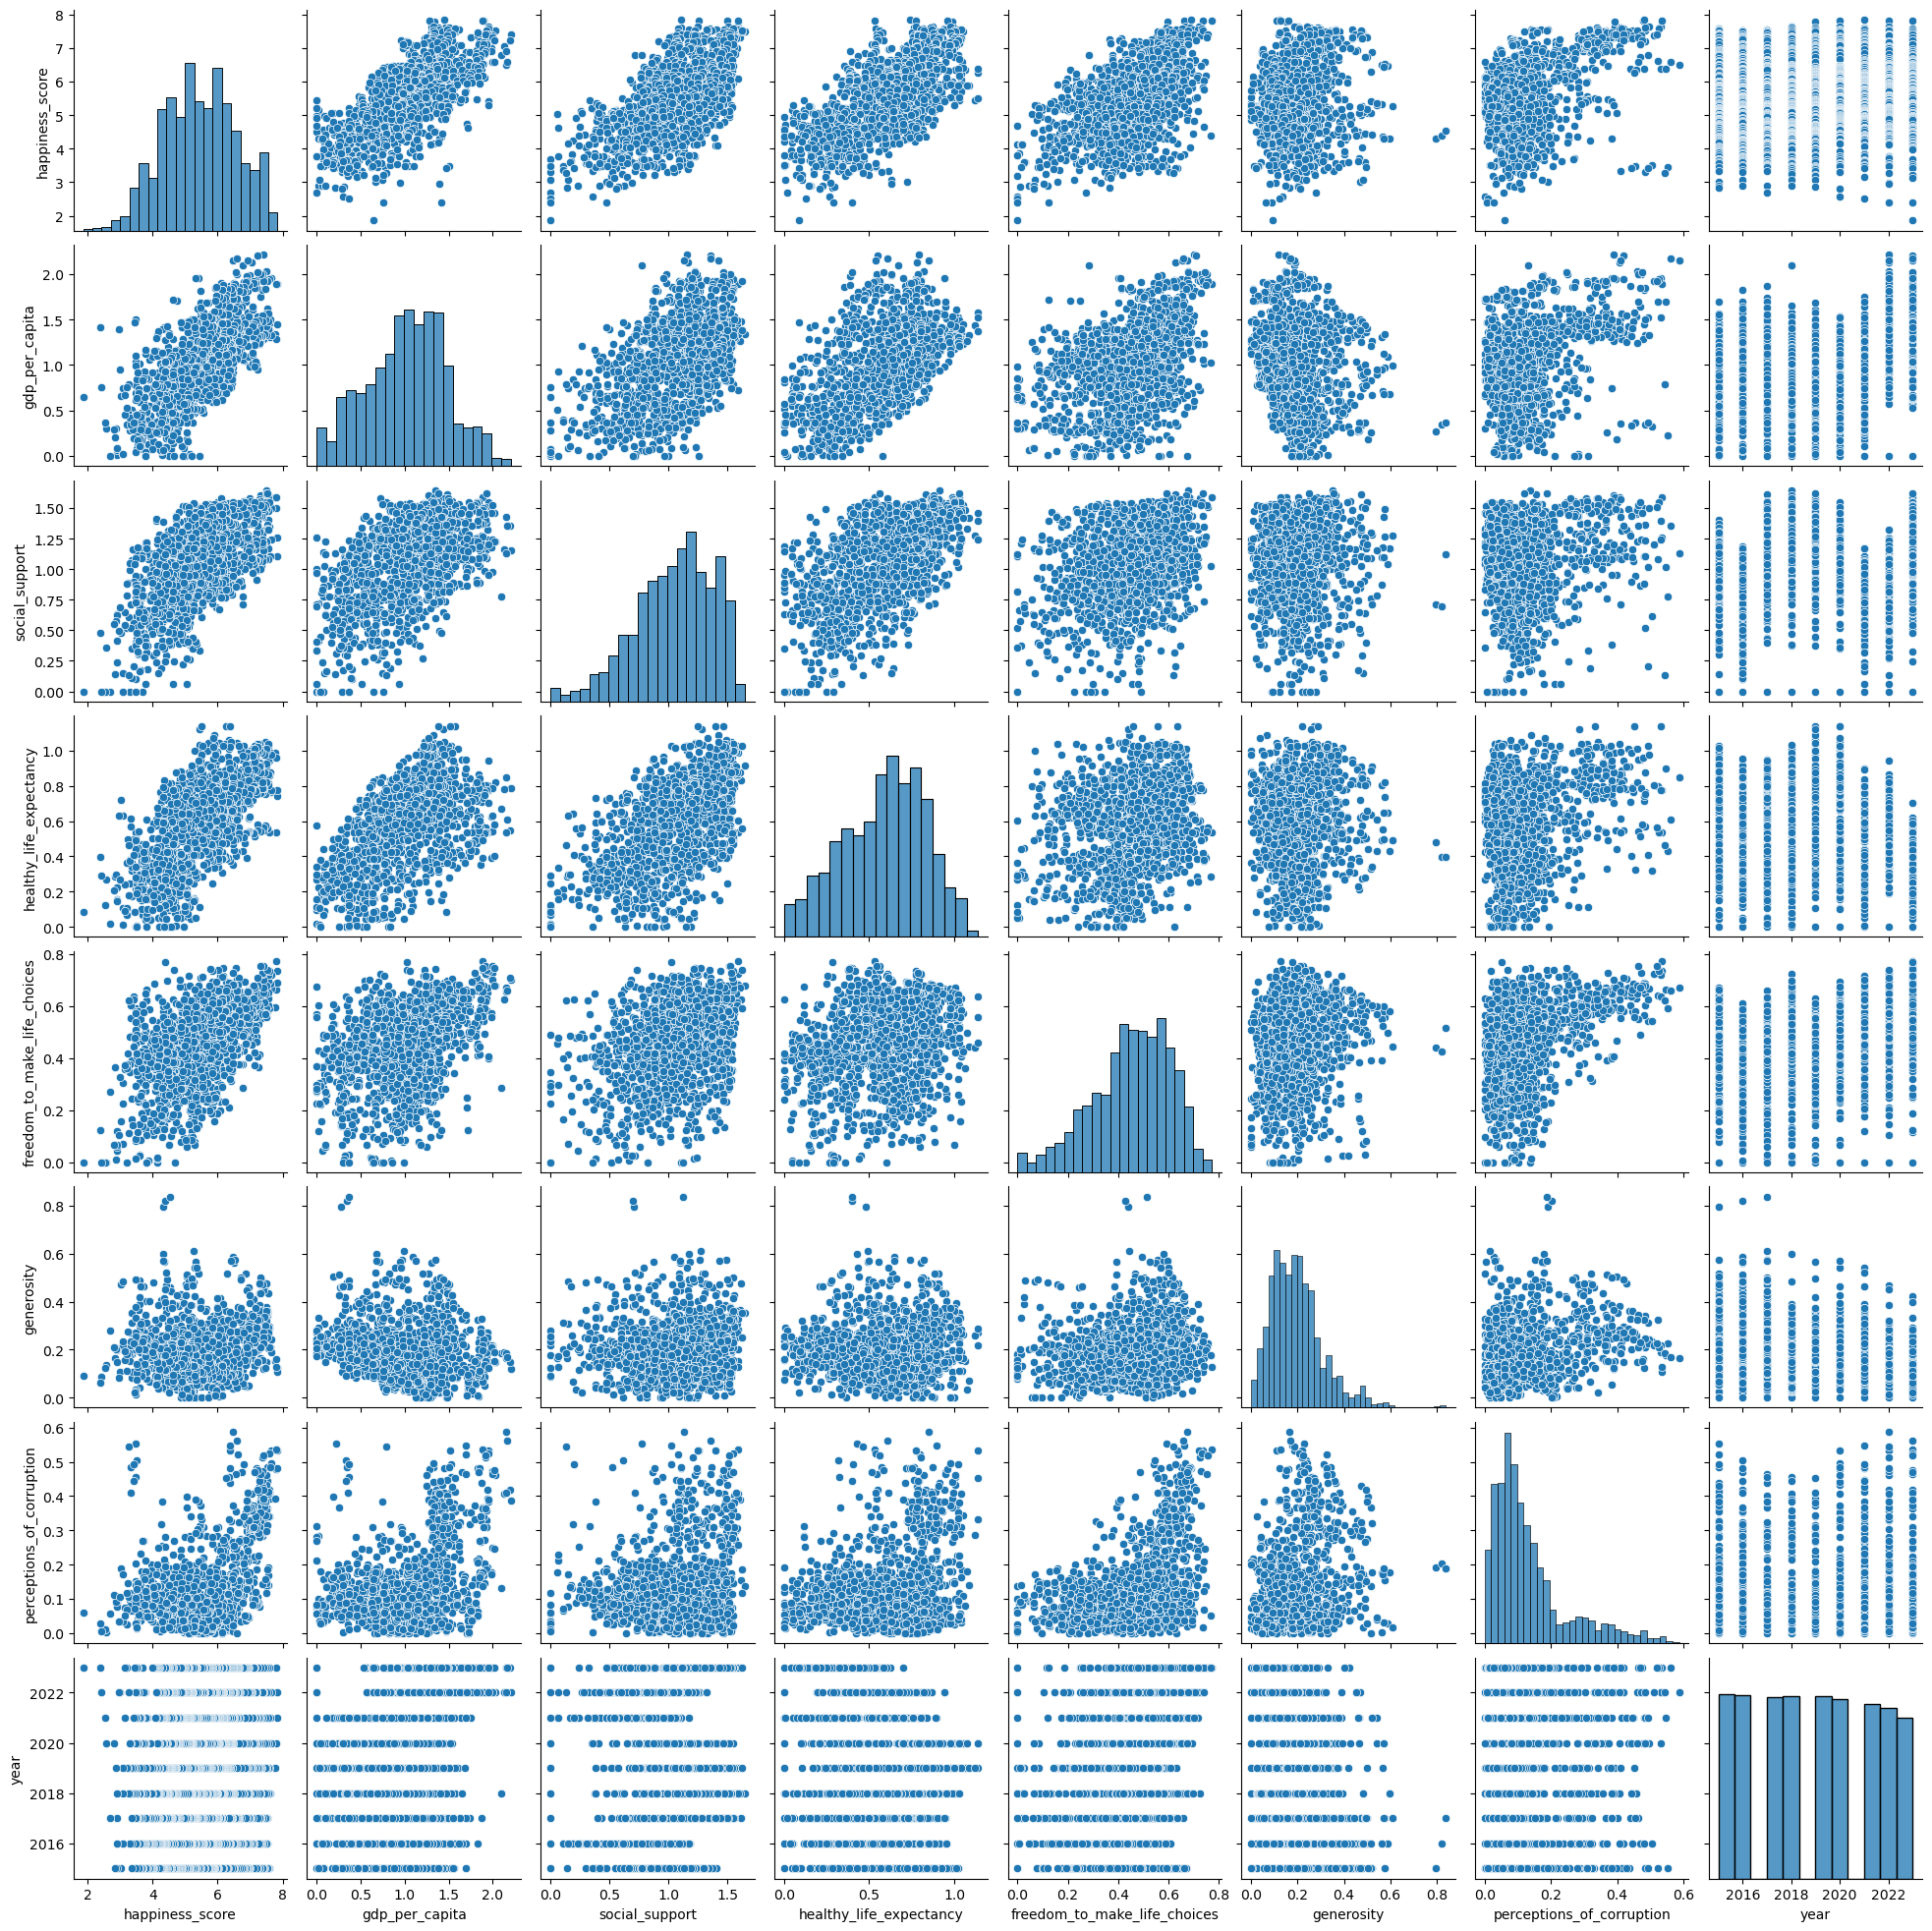

In [11]:
sns.pairplot(concatenated_data)

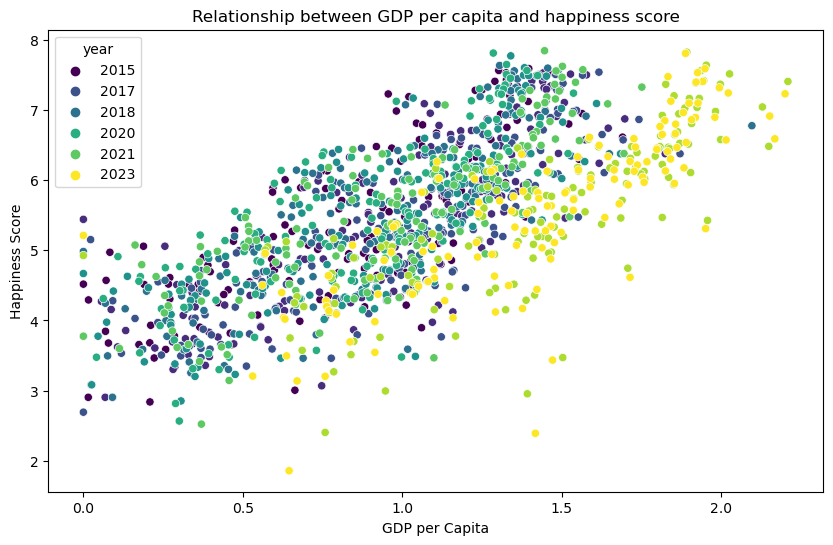

In [12]:
#Grafico del PIB per capita y el score de felicidad 
plt.figure(figsize=(10, 6))
sns.scatterplot(data=concatenated_data, x='gdp_per_capita', y='happiness_score', hue='year', palette='viridis')
plt.title('Relationship between GDP per capita and happiness score')
plt.xlabel('GDP per Capita')
plt.ylabel('Happiness Score')
plt.show()

In [13]:
#Gráfico del score de la felicidad en 2023
df_2023 = concatenated_data.loc[concatenated_data['year'] == 2023]
fig = px.choropleth(df_2023, locations='country', locationmode='country names',scope='world',color='happiness_score', color_continuous_scale= 'Viridis_r')
fig.update_layout(margin={'r':0,'t':0,'l':0,'b':0}, coloraxis_colorbar=dict(
    title = 'happiness_score (2023)',
    ticks = 'outside',
    tickvals = [1,2,3,4,5,6,7,8],
    dtick = 7
))
fig.show()

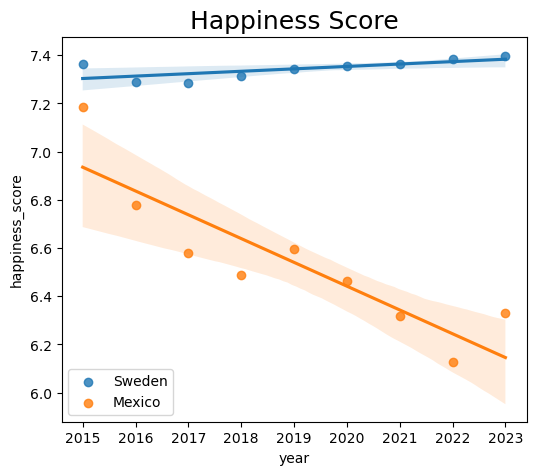

In [14]:
#Comparacion de Suecia y Mexico
sweded_df = concatenated_data.loc[concatenated_data['country'] == 'Sweden']
mexico_df = concatenated_data.loc[concatenated_data['country'] == 'Mexico']

plt.figure(figsize=(6, 5))
sns.regplot(data = sweded_df, x = 'year', y = 'happiness_score', label = 'Sweden')
sns.regplot(data = mexico_df, x = 'year', y = 'happiness_score', label = 'Mexico')
plt.title("Happiness Score", fontsize = 18)
plt.legend()
plt.show()

#### Modelado

In [15]:
# quitamos las variables innecesarias
concatenated_data.drop(["country", "region"], axis=1, inplace=True)


#Dividimos nuestros datos en X y Y
y = concatenated_data["happiness_score"]
X = concatenated_data.drop("happiness_score", axis="columns")

In [16]:
# Dividir el dataset en conjunto de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#### Observar hiperparametros



**Bosque Aleatorio**

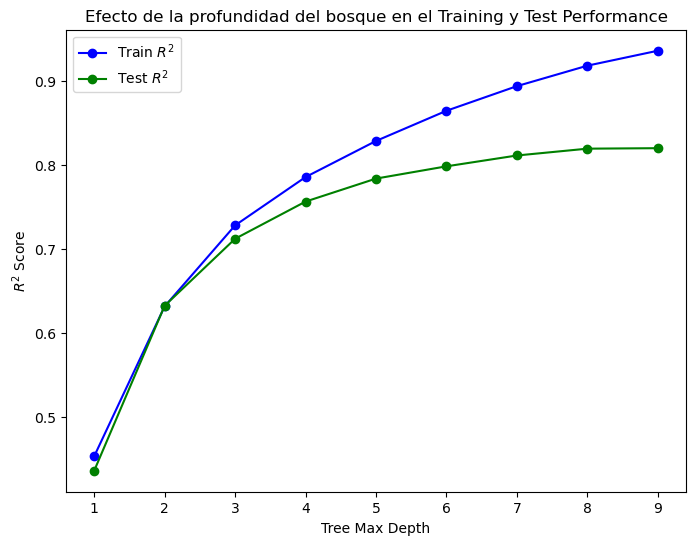

In [17]:
#graficamos la profundidad vs la R2
max_depths = range(1, 10)
train_scores = []
test_scores = []

for max_depth in max_depths:
    tree_reg = RandomForestRegressor(max_depth=max_depth, random_state=42)
    tree_reg.fit(X_train, y_train.values.ravel())
    train_scores.append(tree_reg.score(X_train, y_train))
    test_scores.append(tree_reg.score(X_test, y_test))

# Plotting
plt.figure(figsize=(8, 6))
plt.plot(max_depths, train_scores, label='Train $R^2$', color='blue', marker='o')
plt.plot(max_depths, test_scores, label='Test $R^2$', color='green', marker='o')
plt.xlabel('Tree Max Depth')
plt.ylabel('$R^2$ Score')
plt.title('Efecto de la profundidad del bosque en el Training y Test Performance')
plt.legend()
plt.show()

Podemos elegir profundiades del obsque entre 5 y 7

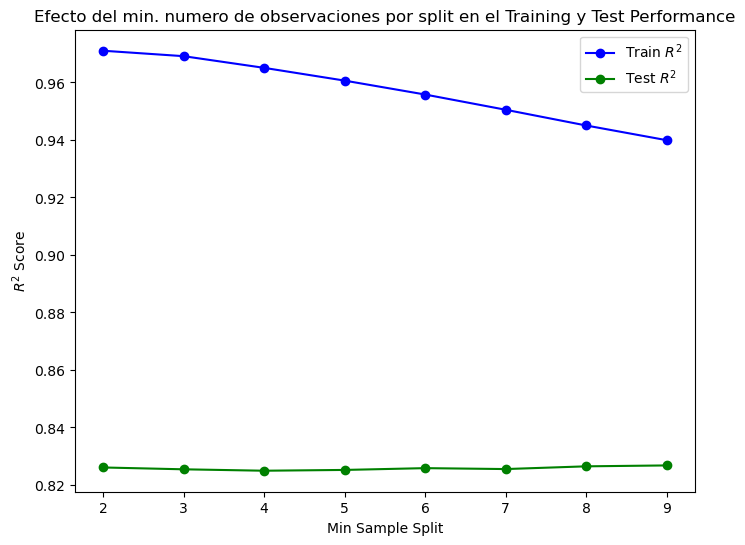

In [18]:
#graficamos el min_sample_split vs la R2
min_samples_splits = range(2, 10)
train_scores = []
test_scores = []

for min_samples_split in min_samples_splits:
    tree_reg = RandomForestRegressor(min_samples_split=min_samples_split, random_state=42)
    tree_reg.fit(X_train, y_train.values.ravel())
    train_scores.append(tree_reg.score(X_train, y_train))
    test_scores.append(tree_reg.score(X_test, y_test))

# Plotting
plt.figure(figsize=(8, 6))
plt.plot(min_samples_splits, train_scores, label='Train $R^2$', color='blue', marker='o')
plt.plot(min_samples_splits, test_scores, label='Test $R^2$', color='green', marker='o')
plt.xlabel('Min Sample Split')
plt.ylabel('$R^2$ Score')
plt.title('Efecto del min. numero de observaciones por split en el Training y Test Performance')
plt.legend()
plt.show()

Podemos elegir entre 8 y 9 min sample split

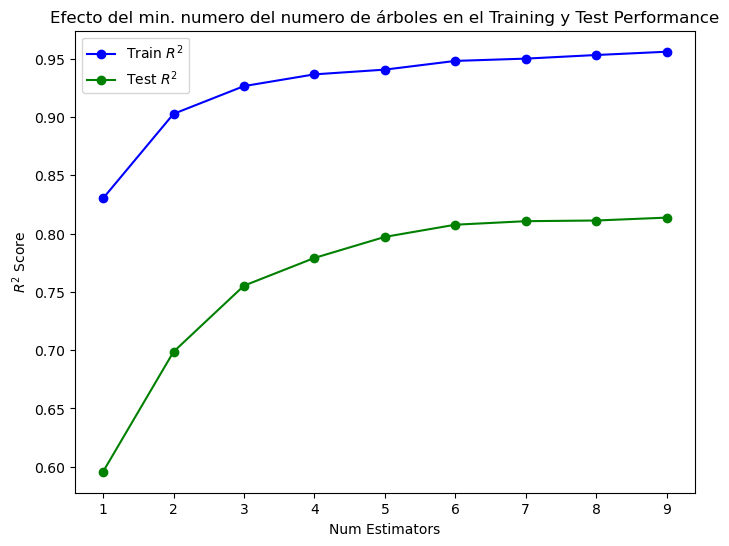

In [19]:
#graficamos el n_estimators vs la R2
n_estimators = range(1, 10)
train_scores = []
test_scores = []

for n_estimator in n_estimators:
    tree_reg = RandomForestRegressor(n_estimators=n_estimator, random_state=42)
    tree_reg.fit(X_train, y_train.values.ravel())
    train_scores.append(tree_reg.score(X_train, y_train))
    test_scores.append(tree_reg.score(X_test, y_test))

# Plotting
plt.figure(figsize=(8, 6))
plt.plot(n_estimators, train_scores, label='Train $R^2$', color='blue', marker='o')
plt.plot(n_estimators, test_scores, label='Test $R^2$', color='green', marker='o')
plt.xlabel('Num Estimators')
plt.ylabel('$R^2$ Score')
plt.title('Efecto del min. numero del numero de árboles en el Training y Test Performance')
plt.legend()
plt.show()

Podemos elegir entre 4 y 6 árboles

**XGBoost**

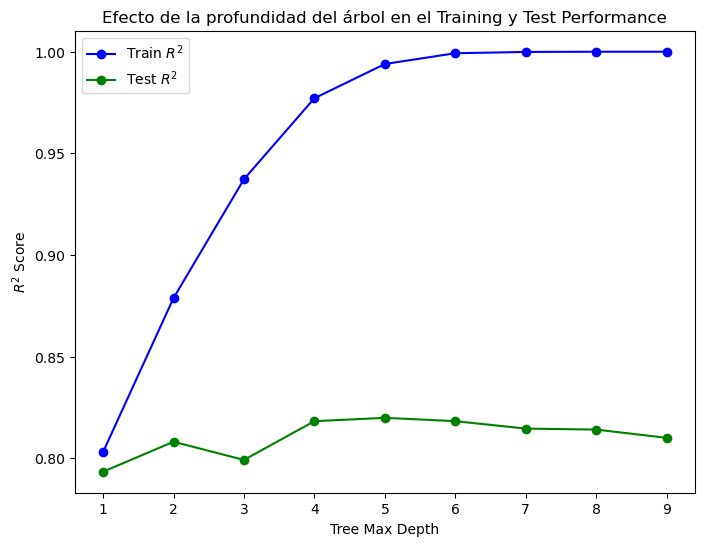

In [20]:
#graficamos la profundidad vs la R2
max_depths = range(1, 10)
train_scores = []
test_scores = []

for max_depth in max_depths:   
    tree_reg = XGBRegressor(max_depth=max_depth, objective='reg:squarederror', seed=42)
    tree_reg.fit(X_train, y_train)
    train_scores.append(tree_reg.score(X_train, y_train))
    test_scores.append(tree_reg.score(X_test, y_test))

# Plotting
plt.figure(figsize=(8, 6))
plt.plot(max_depths, train_scores, label='Train $R^2$', color='blue', marker='o')
plt.plot(max_depths, test_scores, label='Test $R^2$', color='green', marker='o')
plt.xlabel('Tree Max Depth')
plt.ylabel('$R^2$ Score')
plt.title('Efecto de la profundidad del árbol en el Training y Test Performance')
plt.legend()
plt.show()

Podemos elegir entre 2 y 4 profundidades

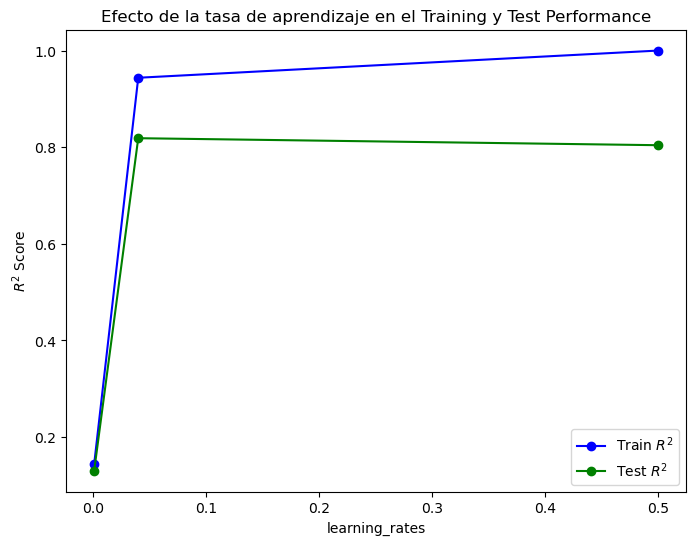

In [21]:
#graficamos la eta (learning_rate) vs la R2
learning_rates = [0.001, 0.04, 0.5]
train_scores = []
test_scores = []

for learning_rate in learning_rates:   
    tree_reg = XGBRegressor(learning_rate=learning_rate, objective='reg:squarederror', seed=42)
    tree_reg.fit(X_train, y_train)
    train_scores.append(tree_reg.score(X_train, y_train))
    test_scores.append(tree_reg.score(X_test, y_test))

# Plotting
plt.figure(figsize=(8, 6))
plt.plot(learning_rates, train_scores, label='Train $R^2$', color='blue', marker='o')
plt.plot(learning_rates, test_scores, label='Test $R^2$', color='green', marker='o')
plt.xlabel('learning_rates')
plt.ylabel('$R^2$ Score')
plt.title('Efecto de la tasa de aprendizaje en el Training y Test Performance')
plt.legend()
plt.show()

Podemos elegir una learning rate de 0.04 

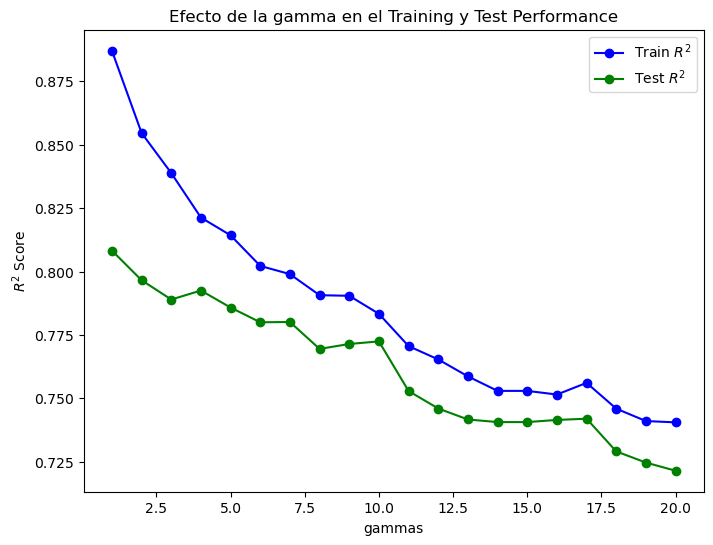

In [22]:
#graficamos la gamma vs la R2
gammas = range(1, 21)
train_scores = []
test_scores = []

for gamma in gammas:   
    tree_reg = XGBRegressor(gamma=gamma, objective='reg:squarederror', seed=42)
    tree_reg.fit(X_train, y_train)
    train_scores.append(tree_reg.score(X_train, y_train))
    test_scores.append(tree_reg.score(X_test, y_test))

# Plotting
plt.figure(figsize=(8, 6))
plt.plot(gammas, train_scores, label='Train $R^2$', color='blue', marker='o')
plt.plot(gammas, test_scores, label='Test $R^2$', color='green', marker='o')
plt.xlabel('gammas')
plt.ylabel('$R^2$ Score')
plt.title('Efecto de la gamma en el Training y Test Performance')
plt.legend()
plt.show()

Podemos elegir una gamma de 1

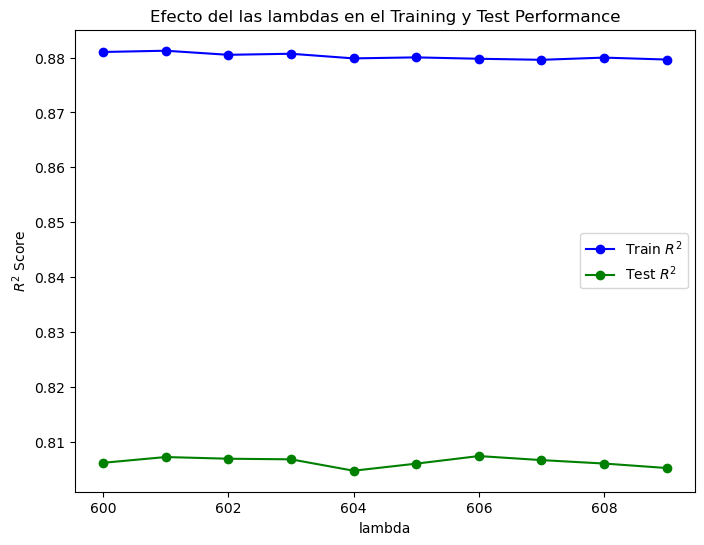

In [23]:
#graficamos la lambda vs la R2
lambdas = range(600, 610)
train_scores = []
test_scores = []

for l in lambdas:
    tree_reg = XGBRegressor(reg_lambda=l, objective='reg:squarederror', seed=42)
    tree_reg.fit(X_train, y_train)
    train_scores.append(tree_reg.score(X_train, y_train))
    test_scores.append(tree_reg.score(X_test, y_test))

# Plotting
plt.figure(figsize=(8, 6))
plt.plot(lambdas, train_scores, label='Train $R^2$', color='blue', marker='o')
plt.plot(lambdas, test_scores, label='Test $R^2$', color='green', marker='o')
plt.xlabel('lambda')
plt.ylabel('$R^2$ Score')
plt.title('Efecto del las lambdas en el Training y Test Performance')
plt.legend()
plt.show()

Podemos elegir una lambda de 606

In [24]:
# Definir los modelos y sus hiperparámetros para GridSearchCV con selección de variables
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import SelectKBest, f_regression

parametros_modelos = {
    'Regresión Lineal': {
        'modelo': Pipeline([
            ('selector', SelectKBest(score_func=f_regression)),  # Selección de características
            ('regressor', LinearRegression())
        ]),
        'params': {
            'selector__k': ['all']  # Número de características a seleccionar
        }
    },
    'Random Forest': {
        'modelo': Pipeline([
            ('selector', SelectKBest(score_func=f_regression)),
            ('regressor', RandomForestRegressor(n_jobs=1))
        ]),
        'params': {
            'selector__k': [3, 5, 'all'],
            'regressor__n_estimators': [4, 5, 6],
            'regressor__max_depth': [5, 6, 7],
            'regressor__min_samples_split': [8, 9]
        }
    },
    'XGBoost': {
        'modelo': Pipeline([
            ('selector', SelectKBest(score_func=f_regression)),
            ('regressor', XGBRegressor(objective='reg:squarederror', random_state=42, reg_lambda=606, gamma=1, learning_rate=0.04, nthread=1))
        ]),
        'params': {
            'selector__k': [3, 5, 'all'],
            'regressor__max_depth': [2, 3, 4]
        }
    }
}


In [25]:
# Evaluar cada modelo con GridSearchCV
resultados_grid = {}
mejores_modelos = {}

for nombre, info in parametros_modelos.items():
    modelo = info['modelo']
    params = info['params']
    grid_search = GridSearchCV(modelo, params, cv=5, scoring='neg_mean_squared_error', error_score='raise')
    grid_search.fit(X_train, y_train)
    mejores_modelos[nombre] = grid_search.best_estimator_
    resultados_grid[nombre] = {
        'Mejores Parámetros': grid_search.best_params_,
        'RMSE CV': np.sqrt(-grid_search.best_score_)
    }

In [26]:
# Convertir resultados en un DataFrame para mejor visualización
resultados_grid_df = pd.DataFrame(resultados_grid).T
resultados_grid_df = resultados_grid_df.sort_values(by='RMSE CV')

print("Resultados de la comparación de modelos (con GridSearchCV):")
print(resultados_grid_df)

Resultados de la comparación de modelos (con GridSearchCV):
                                                 Mejores Parámetros   RMSE CV
Random Forest     {'regressor__max_depth': 7, 'regressor__min_sa...  0.542044
Regresión Lineal                             {'selector__k': 'all'}  0.558984
XGBoost           {'regressor__max_depth': 4, 'selector__k': 'all'}  0.691494


In [27]:
# Elegir el mejor modelo basado en el RMSE de CV
mejor_modelo_nombre = resultados_grid_df.index[0]
mejor_modelo = mejores_modelos[mejor_modelo_nombre]

In [28]:
# Ajustar el mejor modelo con el conjunto de entrenamiento
mejor_modelo.fit(X_train, y_train)

# Predecir en el conjunto de prueba
y_pred = mejor_modelo.predict(X_test)

# Evaluar el modelo en el conjunto de prueba
rmse_test = np.sqrt(mean_squared_error(y_test, y_pred))
r2_test = r2_score(y_test, y_pred)

In [29]:
print(f"\nMejor modelo: {mejor_modelo_nombre}")
print(f"Mejores parámetros: {resultados_grid[mejor_modelo_nombre]['Mejores Parámetros']}")
print(f"RMSE en conjunto de prueba: {rmse_test:.4f}")
print(f"R2 en conjunto de prueba: {r2_test:.4f}")



Mejor modelo: Random Forest
Mejores parámetros: {'regressor__max_depth': 7, 'regressor__min_samples_split': 9, 'regressor__n_estimators': 6, 'selector__k': 'all'}
RMSE en conjunto de prueba: 0.5133
R2 en conjunto de prueba: 0.8077


### Qué seguiría?


- Interpretabilidad: Si es posible, intenta interpretar el modelo. Por ejemplo, si usas un modelo de regresión lineal o un árbol de decisión, analiza la importancia de las variables.

- Errores de Predicción: Analiza los errores de predicción. Observa si hay patrones en los errores que el modelo está cometiendo, como grupos específicos de datos que están siendo mal predichos.

- Documentación del modelo: Documenta el proceso de selección de características, optimización de hiperparámetros y evaluación del modelo.


In [30]:
#Guardar el modelo entrenado

import joblib

# Guardar el mejor modelo
joblib.dump(mejor_modelo, 'mejor_modelo.pkl')

# Cargar el modelo en el futuro
# mejor_modelo_cargado = joblib.load('mejor_modelo.pkl')


['mejor_modelo.pkl']

## Utilizando el mejor modelo para crear predicciones con nuevos datos

In [31]:
concatenated_data.head

<bound method NDFrame.head of       happiness_score  gdp_per_capita  social_support  \
0               7.587         1.39651         1.34951   
1               7.561         1.30232         1.40223   
2               7.527         1.32548         1.36058   
3               7.522         1.45900         1.33095   
4               7.427         1.32629         1.32261   
...               ...             ...             ...   
1362            3.207         0.53100         0.78400   
1363            3.204         0.75800         0.88100   
1364            3.138         0.67000         0.54000   
1365            2.392         1.41700         0.47600   
1366            1.859         0.64500         0.00000   

      healthy_life_expectancy  freedom_to_make_life_choices  generosity  \
0                     0.94143                       0.66557     0.29678   
1                     0.94784                       0.62877     0.43630   
2                     0.87464                       0.64938 

In [32]:
#crear nuevos datos
X_new  = pd.DataFrame([[1.34, 0.5, 0.4, 0.35, 0.3, 0.2, 2024]], columns=['gdp_per_capita', 'social_support',
       'healthy_life_expectancy', 'freedom_to_make_life_choices', 'generosity',
       'perceptions_of_corruption', 'year'])
X_new

,gdp_per_capita,social_support,healthy_life_expectancy,freedom_to_make_life_choices,generosity,perceptions_of_corruption,year
0,1.34,0.5,0.4,0.35,0.3,0.2,2024


In [33]:
# ¿Cuál sería el indice de felicidad?

ynew = mejor_modelo.predict(X_new)



In [34]:
print('el indice de la felicidad seria', ynew)


el indice de la felicidad seria [4.13183895]
